# 04 - Cross-Route Feature Admission Audit

This notebook reviews the engineered features from the direct-fusion, CRISPR-codependency, and directional conditional-dependency notebooks before any predictive model is fitted.

The purpose is quality control, not feature ranking against an answer key. We do not yet have an independent label that says whether every gene pair is biologically valid. Therefore this notebook uses mathematical diagnostics and explicit biological gates, but it does **not** create a weighted quality score or claim a probability.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid', context='notebook')

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'feature_engineering':
    PROJECT_ROOT = PROJECT_ROOT.parent

OUTPUT_DIR = PROJECT_ROOT / 'data' / 'depmap_24Q4' / 'architecture' / 'feature_engineering'
PATHS = {
    'fusion_features': OUTPUT_DIR / 'direct_fusion_pair_features.csv',
    'fusion_audit': OUTPUT_DIR / 'direct_fusion_feature_quality_audit.csv',
    'codependency_features': OUTPUT_DIR / 'crispr_codependency_candidate_features.csv',
    'conditional_features': OUTPUT_DIR / 'directional_conditional_dependency_features.csv',
    'feature_registry': OUTPUT_DIR / 'cross_route_feature_registry.csv',
    'candidate_evidence': OUTPUT_DIR / 'cross_route_candidate_evidence.csv',
    'manifest': OUTPUT_DIR / 'cross_route_feature_audit_manifest.json',
}

missing_inputs = [str(path) for key, path in PATHS.items() if key.endswith('features') or key == 'fusion_audit' if not path.exists()]
assert not missing_inputs, f'Missing feature-engineering inputs: {missing_inputs}'

fusion = pd.read_csv(PATHS['fusion_features'], low_memory=False)
fusion_audit = pd.read_csv(PATHS['fusion_audit'], low_memory=False)
codependency = pd.read_csv(PATHS['codependency_features'], low_memory=False)
conditional = pd.read_csv(PATHS['conditional_features'], low_memory=False)

print(f'Fusion pairs: {len(fusion):,}')
print(f'Codependency candidates: {len(codependency):,}')
print(f'Directional context hypotheses: {len(conditional):,}')

Fusion pairs: 27,256
Codependency candidates: 10
Directional context hypotheses: 16


## 1. Input And Grain Audit

A table's **grain** says what one row represents. Fusion has one row per observed undirected pair, codependency has one row per tested undirected pair, and conditional dependency has one row per directed pair plus molecular context. These grains must not be joined as if they were interchangeable.

In [2]:
input_audit = pd.DataFrame([
    {
        'route_family': 'direct_fusion',
        'rows': len(fusion),
        'unique_keys': fusion['fusion_pair_id'].nunique(),
        'key': 'fusion_pair_id',
        'grain': 'one row per observed undirected fusion pair',
        'duplicate_keys': fusion['fusion_pair_id'].duplicated().sum(),
    },
    {
        'route_family': 'crispr_codependency',
        'rows': len(codependency),
        'unique_keys': codependency['pair_id'].nunique(),
        'key': 'pair_id',
        'grain': 'one row per pre-specified undirected pair',
        'duplicate_keys': codependency['pair_id'].duplicated().sum(),
    },
    {
        'route_family': 'conditional_dependency',
        'rows': len(conditional),
        'unique_keys': conditional['hypothesis_id'].nunique(),
        'key': 'hypothesis_id',
        'grain': 'one row per directed pair and molecular context',
        'duplicate_keys': conditional['hypothesis_id'].duplicated().sum(),
    },
])
display(input_audit)

assert input_audit['duplicate_keys'].eq(0).all()
assert fusion['fusion_assayed_models'].nunique() == 1
assert codependency['route_family'].eq('crispr_codependency').all()
assert conditional['route_family'].eq('conditional_dependency').all()
print('PASS: route grains and primary keys are internally consistent.')

,route_family,rows,unique_keys,key,grain,duplicate_keys
0,direct_fusion,27256,27256,fusion_pair_id,one row per observed undirected fusion pair,0
1,crispr_codependency,10,10,pair_id,one row per pre-specified undirected pair,0
2,conditional_dependency,16,16,hypothesis_id,one row per directed pair and molecular context,0


PASS: route grains and primary keys are internally consistent.


### What this means biologically

A fusion row means an RNA breakpoint connecting two genes was observed. A codependency row means two knockout profiles were compared across cell lines. A conditional row asks whether a state in Gene A changes dependency on Gene B. Keeping these meanings separate is part of the white-box design.

## 2. Mathematical Quality And Admission Gates

The audit measures non-missing coverage, number of distinct values, and Spearman redundancy within each route. Correlation is descriptive when fewer than 30 route rows are available. The decision is not made by a single mathematical score: each feature also needs a biological meaning, reproducible formula, denominator, missingness rule, provenance, and leakage review.

In [3]:
def feature_spec(feature_name, feature_role, decision, rationale, lineage_gate='not_applicable'):
    return {
        'feature_name': feature_name,
        'feature_role': feature_role,
        'pre_label_decision': decision,
        'biological_rationale': rationale,
        'lineage_confounding_gate': lineage_gate,
    }

codependency_specs = [
    feature_spec('codependency_rho_adjusted', 'biological_route', 'keep_candidate', 'Primary lineage-adjusted similarity between two CRISPR knockout profiles.', 'pass_adjusted'),
    feature_spec('codependency_rho_raw', 'diagnostic', 'diagnostic_only', 'Unadjusted association retained to show how much lineage adjustment changes the result.', 'fail_unadjusted'),
    feature_spec('shared_models', 'confidence_context', 'confidence_only', 'Actual number of models with both gene-effect measurements.'),
    feature_spec('eligible_lineages', 'confidence_context', 'confidence_only', 'Number of sufficiently represented disease lineages contributing to the estimate.'),
    feature_spec('bootstrap_ci_low', 'confidence_context', 'confidence_only', 'Lower resampling bound for the adjusted association.'),
    feature_spec('bootstrap_ci_high', 'confidence_context', 'confidence_only', 'Upper resampling bound for the adjusted association.'),
    feature_spec('bootstrap_ci_width', 'confidence_context', 'confidence_only', 'Uncertainty width; narrower is more precise but is not stronger biology.'),
    feature_spec('loo_sign_consistency', 'confidence_context', 'confidence_only', 'Fraction of leave-one-lineage-out estimates retaining the full-data sign.'),
    feature_spec('qc_passing_fraction', 'technical_confidence', 'confidence_only', 'Fraction of contributing models with acceptable released CRISPR QC context.'),
    feature_spec('coverage_fraction_of_crispr_models', 'confidence_context', 'confidence_only', 'Assay coverage for this pair relative to the eligible CRISPR cohort.'),
    feature_spec('common_essential_warning', 'biological_warning', 'confidence_only', 'Warns that broad cell-survival biology may dominate a selective relationship.'),
    feature_spec('adjusted_p_value', 'statistical_diagnostic', 'diagnostic_only', 'Tests association under the current candidate set; it is not an effect size.'),
    feature_spec('fdr_bh', 'statistical_diagnostic', 'diagnostic_only', 'Multiple-testing diagnostic tied to this small pre-specified candidate set.'),
]

conditional_specs = [
    feature_spec('dependency_shift_adjusted', 'biological_route', 'keep_candidate', 'Primary effect: positive means stronger Gene-B dependency in the Gene-A context.', 'pass_adjusted'),
    feature_spec('dependency_shift_raw', 'diagnostic', 'diagnostic_only', 'Unadjusted shift retained to reveal lineage confounding.', 'fail_unadjusted'),
    feature_spec('dependency_rank_effect_adjusted', 'supporting_effect', 'supporting_only', 'Rank-based companion effect robust to extreme values.', 'pass_adjusted'),
    feature_spec('dependency_probability_shift', 'supporting_effect', 'supporting_only', 'Difference in probability-like dependency calls; useful for interpretation, not calibration.'),
    feature_spec('context_models', 'confidence_context', 'confidence_only', 'Measured models carrying the declared Gene-A context.'),
    feature_spec('reference_models', 'confidence_context', 'confidence_only', 'Measured models in the explicit comparison group.'),
    feature_spec('eligible_lineages', 'confidence_context', 'confidence_only', 'Disease lineages meeting the group-size rules.'),
    feature_spec('bootstrap_ci_low', 'confidence_context', 'confidence_only', 'Lower resampling bound for the adjusted dependency shift.'),
    feature_spec('bootstrap_ci_high', 'confidence_context', 'confidence_only', 'Upper resampling bound for the adjusted dependency shift.'),
    feature_spec('bootstrap_ci_width', 'confidence_context', 'confidence_only', 'Uncertainty width for the adjusted shift.'),
    feature_spec('loo_sign_consistency', 'confidence_context', 'confidence_only', 'Sensitivity of effect direction to removing one eligible lineage.'),
    feature_spec('context_prevalence_in_comparison', 'cohort_description', 'supporting_only', 'How common the molecular context is in the measured comparison cohort.'),
    feature_spec('common_essential_target', 'biological_warning', 'confidence_only', 'Warns when Gene B is broadly required for cell survival.'),
    feature_spec('qc_passing_fraction', 'technical_confidence', 'confidence_only', 'Released CRISPR QC coverage for contributing models.'),
    feature_spec('adjusted_p_value', 'statistical_diagnostic', 'diagnostic_only', 'Statistical diagnostic, not biological effect magnitude.'),
    feature_spec('fdr_bh', 'statistical_diagnostic', 'diagnostic_only', 'Candidate-set multiple-testing diagnostic, not a model feature.'),
]

route_tables = {
    'crispr_codependency': codependency,
    'conditional_dependency': conditional,
}
route_specs = {
    'crispr_codependency': codependency_specs,
    'conditional_dependency': conditional_specs,
}

registry_rows = []
for route_family, specs in route_specs.items():
    table = route_tables[route_family]
    feature_names = [spec['feature_name'] for spec in specs]
    numeric = table[feature_names].apply(pd.to_numeric, errors='coerce')
    correlation = numeric.corr(method='spearman')
    for spec in specs:
        feature_name = spec['feature_name']
        other_correlations = correlation[feature_name].drop(feature_name).abs().dropna()
        most_correlated = other_correlations.idxmax() if not other_correlations.empty else pd.NA
        pair_n = table[[feature_name, most_correlated]].dropna().shape[0] if pd.notna(most_correlated) else 0
        registry_rows.append({
            'route_family': route_family,
            **spec,
            'non_missing_fraction': table[feature_name].notna().mean(),
            'unique_values': table[feature_name].nunique(dropna=True),
            'most_correlated_feature': most_correlated,
            'max_abs_spearman': other_correlations.max() if not other_correlations.empty else np.nan,
            'redundancy_sample_size': pair_n,
            'redundancy_interpretation': 'actionable_screen' if pair_n >= 30 else 'descriptive_small_candidate_set',
            'biology_gate': 'pass',
            'formula_gate': 'pass',
            'denominator_gate': 'pass',
            'missingness_gate': 'pass',
            'leakage_gate': 'pass',
            'provenance_gate': 'pass',
        })

new_registry = pd.DataFrame(registry_rows)
fusion_registry = fusion_audit.copy()
fusion_registry['redundancy_interpretation'] = np.where(
    fusion_registry['redundancy_sample_size'].ge(30), 'actionable_screen', 'descriptive_small_candidate_set'
)
fusion_registry['biology_gate'] = 'pass'
fusion_registry['formula_gate'] = 'pass'
fusion_registry['denominator_gate'] = 'pass'
fusion_registry['missingness_gate'] = 'pass'
fusion_registry['lineage_confounding_gate'] = 'not_applicable_route_description'
fusion_registry['provenance_gate'] = 'pass'

registry_columns = [
    'route_family', 'feature_name', 'feature_role', 'pre_label_decision',
    'non_missing_fraction', 'unique_values', 'most_correlated_feature',
    'max_abs_spearman', 'redundancy_sample_size', 'redundancy_interpretation',
    'biology_gate', 'formula_gate', 'denominator_gate', 'missingness_gate',
    'lineage_confounding_gate', 'leakage_gate', 'provenance_gate',
    'biological_rationale',
]
feature_registry = pd.concat([
    fusion_registry.reindex(columns=registry_columns),
    new_registry.reindex(columns=registry_columns),
], ignore_index=True)

display(feature_registry)
assert feature_registry[['route_family', 'feature_name']].duplicated().sum() == 0
assert feature_registry['leakage_gate'].eq('pass').all()
assert feature_registry.loc[feature_registry['pre_label_decision'].eq('keep_candidate'), 'biology_gate'].eq('pass').all()
print('PASS: every retained candidate has an explicit role and passes the required pre-label gates.')

,route_family,feature_name,feature_role,pre_label_decision,non_missing_fraction,unique_values,most_correlated_feature,max_abs_spearman,redundancy_sample_size,redundancy_interpretation,biology_gate,formula_gate,denominator_gate,missingness_gate,lineage_confounding_gate,leakage_gate,provenance_gate,biological_rationale
0,direct_fusion,models_with_fusion,biological_route,keep_candidate,1.000000,75,fusion_model_fraction,1.000000,27256,actionable_screen,pass,pass,pass,pass,not_applicable_route_description,pass,pass,Observed recurrence numerator.
1,direct_fusion,fusion_model_fraction,display,supporting_only,1.000000,75,models_with_fusion,1.000000,27256,actionable_screen,pass,pass,pass,pass,not_applicable_route_description,pass,pass,Exact transform of recurrence count because th...
2,direct_fusion,filtered_calls_total,technical_confidence,supporting_only,1.000000,84,models_with_fusion,0.610427,27256,actionable_screen,pass,pass,pass,pass,not_applicable_route_description,pass,pass,Repeated calls can track recurrence and requir...
3,direct_fusion,junction_reads_total,technical_confidence,supporting_only,1.000000,637,junction_reads_median_per_model,0.945978,27256,actionable_screen,pass,pass,pass,pass,not_applicable_route_description,pass,pass,Total support can rise with the number of posi...
4,direct_fusion,junction_reads_median_per_model,technical_confidence,keep_candidate,1.000000,661,junction_reads_total,0.945978,27256,actionable_screen,pass,pass,pass,pass,not_applicable_route_description,pass,pass,Robust typical junction support per positive m...
5,direct_fusion,spanning_fragments_total,technical_confidence,supporting_only,1.000000,698,spanning_fragments_median_per_model,0.978455,27256,actionable_screen,pass,pass,pass,pass,not_applicable_route_description,pass,pass,Total support can rise with recurrence.
6,direct_fusion,spanning_fragments_median_per_model,technical_confidence,keep_candidate,1.000000,711,spanning_fragments_total,0.978455,27256,actionable_screen,pass,pass,pass,pass,not_applicable_route_description,pass,pass,Robust typical spanning support per positive m...
7,direct_fusion,max_ffpm,technical_confidence,supporting_only,1.000000,7180,median_ffpm,0.984731,27256,actionable_screen,pass,pass,pass,pass,not_applicable_route_description,pass,pass,Strongest abundance can be driven by one model.
8,direct_fusion,median_ffpm,technical_confidence,keep_candidate,1.000000,7648,max_ffpm,0.984731,27256,actionable_screen,pass,pass,pass,pass,not_applicable_route_description,pass,pass,Typical abundance across positive models.
9,direct_fusion,models_with_large_anchor,technical_confidence,supporting_only,1.000000,75,models_with_fusion,0.865805,27256,actionable_screen,pass,pass,pass,pass,not_applicable_route_description,pass,pass,Count is partly determined by recurrence.


PASS: every retained candidate has an explicit role and passes the required pre-label gates.


### How to read this audit

`keep_candidate` means a feature is biologically and mathematically defensible enough to test later. It does not mean the feature is proven useful. `confidence_only` fields tell us how much to trust a measurement, `supporting_only` fields help interpretation, and `diagnostic_only` fields expose confounding or statistical behaviour. Final feature selection must happen inside training folds after an independent outcome is defined.

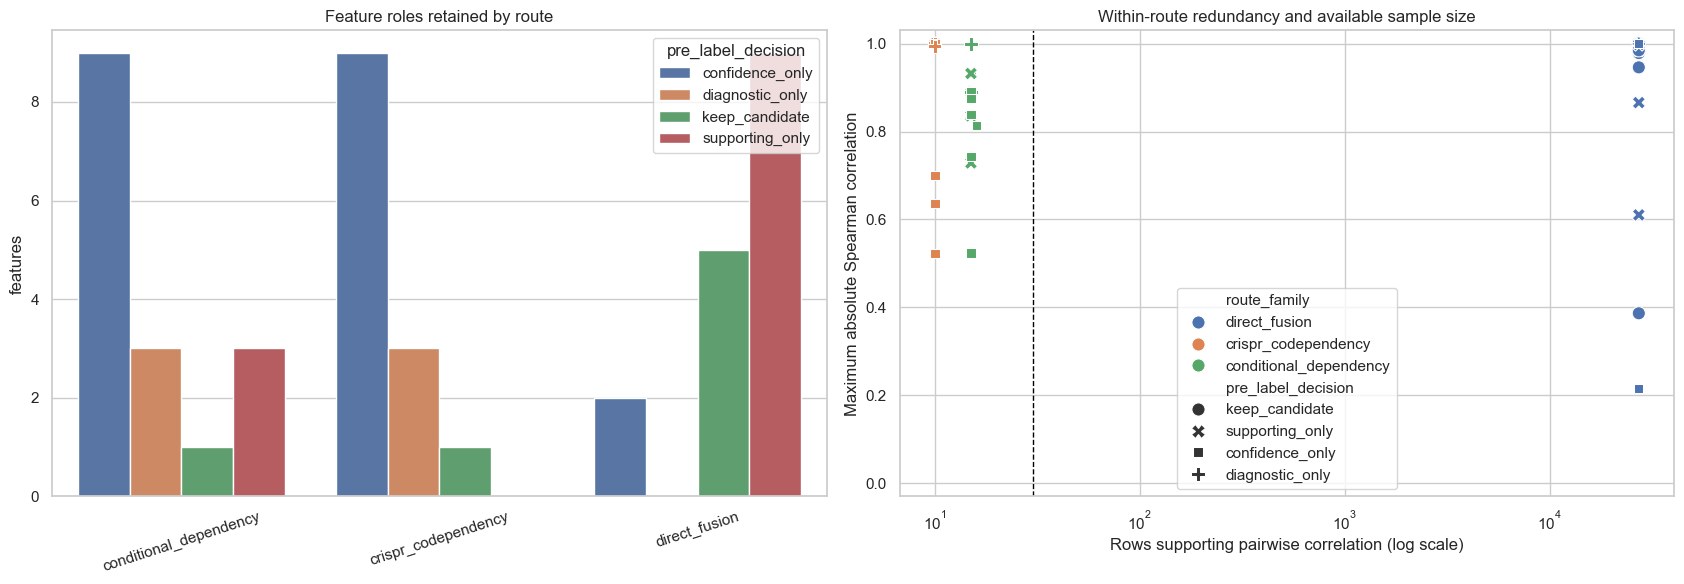

,route_family,feature_name,most_correlated_feature,max_abs_spearman,redundancy_sample_size,redundancy_interpretation,pre_label_decision
43,conditional_dependency,adjusted_p_value,fdr_bh,0.999107,15,descriptive_small_candidate_set,diagnostic_only
44,conditional_dependency,fdr_bh,adjusted_p_value,0.999107,15,descriptive_small_candidate_set,diagnostic_only
34,conditional_dependency,reference_models,context_prevalence_in_comparison,0.932021,15,descriptive_small_candidate_set,confidence_only
40,conditional_dependency,context_prevalence_in_comparison,reference_models,0.932021,15,descriptive_small_candidate_set,supporting_only
16,crispr_codependency,codependency_rho_adjusted,bootstrap_ci_low,1.000000,10,descriptive_small_candidate_set,keep_candidate
17,crispr_codependency,codependency_rho_raw,bootstrap_ci_high,1.000000,10,descriptive_small_candidate_set,diagnostic_only
20,crispr_codependency,bootstrap_ci_low,codependency_rho_adjusted,1.000000,10,descriptive_small_candidate_set,confidence_only
21,crispr_codependency,bootstrap_ci_high,codependency_rho_raw,1.000000,10,descriptive_small_candidate_set,confidence_only
27,crispr_codependency,adjusted_p_value,fdr_bh,0.993921,10,descriptive_small_candidate_set,diagnostic_only
28,crispr_codependency,fdr_bh,adjusted_p_value,0.993921,10,descriptive_small_candidate_set,diagnostic_only


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6))

decision_counts = (
    feature_registry.groupby(['route_family', 'pre_label_decision'])
    .size().rename('features').reset_index()
)
sns.barplot(data=decision_counts, x='route_family', y='features', hue='pre_label_decision', ax=axes[0])
axes[0].set_title('Feature roles retained by route')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=18)

plot_registry = feature_registry.copy()
plot_registry['sample_size_for_plot'] = plot_registry['redundancy_sample_size'].clip(lower=1)
sns.scatterplot(
    data=plot_registry, x='sample_size_for_plot', y='max_abs_spearman',
    hue='route_family', style='pre_label_decision', s=90, ax=axes[1],
)
axes[1].axvline(30, color='black', linestyle='--', linewidth=1)
axes[1].set_xscale('log')
axes[1].set_ylim(-0.03, 1.03)
axes[1].set_title('Within-route redundancy and available sample size')
axes[1].set_xlabel('Rows supporting pairwise correlation (log scale)')
axes[1].set_ylabel('Maximum absolute Spearman correlation')

plt.tight_layout()
plt.show()

display(
    feature_registry.loc[
        feature_registry['max_abs_spearman'].ge(0.90),
        ['route_family', 'feature_name', 'most_correlated_feature', 'max_abs_spearman',
         'redundancy_sample_size', 'redundancy_interpretation', 'pre_label_decision']
    ].sort_values(['route_family', 'max_abs_spearman'], ascending=[True, False])
)

### Mathematical decision

The 27,256 observed fusion pairs support a useful redundancy screen. The 10 codependency pairs and 16 conditional hypotheses are deliberately small hypothesis sets, so their correlations are shown but cannot justify deleting features. For example, an interval bound can correlate strongly with its effect estimate while still being needed to communicate uncertainty.

## 3. Long Cross-Route Candidate Evidence

The next artifact indexes the currently declared candidate pairs without combining their numbers. An absent exact fusion call can be recorded as `measured_no_observed_call` because the fusion assay denominator is known. A pair not included in the small codependency or conditional hypothesis set is `not_evaluated` or `not_declared`, never zero.

In [5]:
def canonical_pair(gene_a, gene_b):
    return '--'.join(sorted([str(gene_a), str(gene_b)]))

codependency_pairs = {
    canonical_pair(row.gene_a, row.gene_b)
    for row in codependency.itertuples(index=False)
}
conditional_pairs = {
    canonical_pair(row.context_gene, row.target_gene)
    for row in conditional.itertuples(index=False)
}
candidate_pairs = sorted(codependency_pairs | conditional_pairs)

fusion = fusion.copy()
fusion['canonical_pair_id'] = [canonical_pair(a, b) for a, b in zip(fusion['gene_a_symbol'], fusion['gene_b_symbol'])]
fusion_lookup = fusion.set_index('canonical_pair_id', drop=False)
fusion_denominator = int(fusion['fusion_assayed_models'].iloc[0])
zero_wilson_high = 1.96**2 / (fusion_denominator + 1.96**2)

evidence_rows = []
for pair_id in candidate_pairs:
    gene_a, gene_b = pair_id.split('--', 1)
    if pair_id in fusion_lookup.index:
        row = fusion_lookup.loc[pair_id]
        if isinstance(row, pd.DataFrame):
            raise ValueError(f'Duplicate canonical fusion pair: {pair_id}')
        evidence_rows.append({
            'pair_id': pair_id,
            'directional_pair_id': pd.NA,
            'context_type': pd.NA,
            'route_family': 'direct_fusion',
            'route_state': 'measured_observed_pair',
            'primary_feature_name': 'models_with_fusion',
            'primary_feature_value': row['models_with_fusion'],
            'models_measured': row['fusion_assayed_models'],
            'context_models': pd.NA,
            'reference_models': pd.NA,
            'eligible_lineages': row['lineages_with_fusion'],
            'ci_low': row['recurrence_ci_low'],
            'ci_high': row['recurrence_ci_high'],
            'stability_review': 'see_loo_recurrence_max_abs_deviation',
            'warning_flag': False,
            'value_direction': 'larger count means more recurrent observed RNA fusion',
        })
    else:
        evidence_rows.append({
            'pair_id': pair_id,
            'directional_pair_id': pd.NA,
            'context_type': pd.NA,
            'route_family': 'direct_fusion',
            'route_state': 'measured_no_observed_call',
            'primary_feature_name': 'models_with_fusion',
            'primary_feature_value': 0,
            'models_measured': fusion_denominator,
            'context_models': pd.NA,
            'reference_models': pd.NA,
            'eligible_lineages': 0,
            'ci_low': 0.0,
            'ci_high': zero_wilson_high,
            'stability_review': 'no retained exact call in assayed cohort',
            'warning_flag': False,
            'value_direction': 'zero means no retained exact call, not biological incompatibility',
        })

codependency = codependency.copy()
codependency['canonical_pair_id'] = [canonical_pair(a, b) for a, b in zip(codependency['gene_a'], codependency['gene_b'])]
codependency_lookup = codependency.set_index('canonical_pair_id', drop=False)
for pair_id in candidate_pairs:
    if pair_id in codependency_lookup.index:
        row = codependency_lookup.loc[pair_id]
        evidence_rows.append({
            'pair_id': pair_id,
            'directional_pair_id': pd.NA,
            'context_type': pd.NA,
            'route_family': 'crispr_codependency',
            'route_state': row['route_state'],
            'primary_feature_name': 'codependency_rho_adjusted',
            'primary_feature_value': row['codependency_rho_adjusted'],
            'models_measured': row['shared_models'],
            'context_models': pd.NA,
            'reference_models': pd.NA,
            'eligible_lineages': row['eligible_lineages'],
            'ci_low': row['bootstrap_ci_low'],
            'ci_high': row['bootstrap_ci_high'],
            'stability_review': row['stability_review'],
            'warning_flag': row['common_essential_warning'],
            'value_direction': 'positive means similar lineage-adjusted knockout profiles',
        })
    else:
        evidence_rows.append({
            'pair_id': pair_id,
            'directional_pair_id': pd.NA,
            'context_type': pd.NA,
            'route_family': 'crispr_codependency',
            'route_state': 'not_evaluated_candidate_set',
            'primary_feature_name': 'codependency_rho_adjusted',
            'primary_feature_value': np.nan,
            'models_measured': pd.NA,
            'context_models': pd.NA,
            'reference_models': pd.NA,
            'eligible_lineages': pd.NA,
            'ci_low': np.nan,
            'ci_high': np.nan,
            'stability_review': 'not evaluated by notebook 02 candidate set',
            'warning_flag': pd.NA,
            'value_direction': 'missing evidence is not zero',
        })

conditional = conditional.copy()
conditional['canonical_pair_id'] = [canonical_pair(a, b) for a, b in zip(conditional['context_gene'], conditional['target_gene'])]
for pair_id in candidate_pairs:
    pair_rows = conditional.loc[conditional['canonical_pair_id'].eq(pair_id)]
    if pair_rows.empty:
        evidence_rows.append({
            'pair_id': pair_id,
            'directional_pair_id': pd.NA,
            'context_type': pd.NA,
            'route_family': 'conditional_dependency',
            'route_state': 'not_declared_hypothesis',
            'primary_feature_name': 'dependency_shift_adjusted',
            'primary_feature_value': np.nan,
            'models_measured': pd.NA,
            'context_models': pd.NA,
            'reference_models': pd.NA,
            'eligible_lineages': pd.NA,
            'ci_low': np.nan,
            'ci_high': np.nan,
            'stability_review': 'no directional molecular-context hypothesis declared',
            'warning_flag': pd.NA,
            'value_direction': 'missing evidence is not zero',
        })
    else:
        for row in pair_rows.itertuples(index=False):
            evidence_rows.append({
                'pair_id': pair_id,
                'directional_pair_id': row.directional_pair_id,
                'context_type': row.context_type,
                'route_family': 'conditional_dependency',
                'route_state': row.route_state,
                'primary_feature_name': 'dependency_shift_adjusted',
                'primary_feature_value': row.dependency_shift_adjusted,
                'models_measured': row.context_models + row.reference_models,
                'context_models': row.context_models,
                'reference_models': row.reference_models,
                'eligible_lineages': row.eligible_lineages,
                'ci_low': row.bootstrap_ci_low,
                'ci_high': row.bootstrap_ci_high,
                'stability_review': row.stability_review,
                'warning_flag': bool(row.common_essential_target),
                'value_direction': 'positive means stronger Gene-B dependency in Gene-A context',
            })

candidate_evidence = pd.DataFrame(evidence_rows).sort_values(
    ['pair_id', 'route_family', 'directional_pair_id', 'context_type'], na_position='last'
).reset_index(drop=True)

display(candidate_evidence)
assert set(candidate_pairs) == set(candidate_evidence['pair_id'])
assert candidate_evidence.loc[
    candidate_evidence['route_state'].isin(['not_evaluated_candidate_set', 'not_declared_hypothesis']),
    'primary_feature_value'
].isna().all()
assert candidate_evidence.loc[
    candidate_evidence['route_state'].eq('measured_no_observed_call'),
    'models_measured'
].eq(fusion_denominator).all()
print('PASS: missing route evidence remains missing, while measured fusion absence keeps its assay denominator.')

,pair_id,directional_pair_id,context_type,route_family,route_state,primary_feature_name,primary_feature_value,models_measured,context_models,reference_models,eligible_lineages,ci_low,ci_high,stability_review,warning_flag,value_direction
0,ABL1--BCR,<NA>,<NA>,conditional_dependency,not_declared_hypothesis,dependency_shift_adjusted,NaN,<NA>,<NA>,<NA>,<NA>,NaN,NaN,no directional molecular-context hypothesis de...,<NA>,missing evidence is not zero
1,ABL1--BCR,<NA>,<NA>,crispr_codependency,measured,codependency_rho_adjusted,0.086601,1143,<NA>,<NA>,22,0.034377,0.151522,stable_direction_and_interval,False,positive means similar lineage-adjusted knocko...
2,ABL1--BCR,<NA>,<NA>,direct_fusion,measured_observed_pair,models_with_fusion,24.000000,1672,<NA>,<NA>,2,0.009665,0.021270,see_loo_recurrence_max_abs_deviation,False,larger count means more recurrent observed RNA...
3,ALK--EML4,<NA>,<NA>,conditional_dependency,not_declared_hypothesis,dependency_shift_adjusted,NaN,<NA>,<NA>,<NA>,<NA>,NaN,NaN,no directional molecular-context hypothesis de...,<NA>,missing evidence is not zero
4,ALK--EML4,<NA>,<NA>,crispr_codependency,measured,codependency_rho_adjusted,-0.046801,1143,<NA>,<NA>,22,-0.110444,0.016877,stable_direction_uncertain_interval,False,positive means similar lineage-adjusted knocko...
5,ALK--EML4,<NA>,<NA>,direct_fusion,measured_observed_pair,models_with_fusion,7.000000,1672,<NA>,<NA>,4,0.002029,0.008617,see_loo_recurrence_max_abs_deviation,False,larger count means more recurrent observed RNA...
6,ARID1A--EZH2,ARID1A -> EZH2,mutation,conditional_dependency,measured,dependency_shift_adjusted,0.033661,1143,116,1027,22,0.000812,0.061391,stable_direction_and_interval,False,positive means stronger Gene-B dependency in G...
7,ARID1A--EZH2,<NA>,<NA>,crispr_codependency,measured,codependency_rho_adjusted,0.001629,1143,<NA>,<NA>,22,-0.060377,0.062422,lineage_sensitive_or_uncertain,False,positive means similar lineage-adjusted knocko...
8,ARID1A--EZH2,<NA>,<NA>,direct_fusion,measured_no_observed_call,models_with_fusion,0.000000,1672,<NA>,<NA>,0,0.000000,0.002292,no retained exact call in assayed cohort,False,"zero means no retained exact call, not biologi..."
9,BRAF--MAP2K1,BRAF -> MAP2K1,mutation,conditional_dependency,measured,dependency_shift_adjusted,0.144021,1143,90,1053,22,0.099649,0.201356,stable_direction_and_interval,False,positive means stronger Gene-B dependency in G...


PASS: missing route evidence remains missing, while measured fusion absence keeps its assay denominator.


### Biological example

A pair can have no observed fusion but still show codependency or a directional vulnerability. That is not a contradiction: the routes measure different mechanisms. Conversely, observing a fusion transcript does not prove the two separate genes have similar knockout profiles. The dashboard should explain which route was measured rather than forcing all routes to agree.

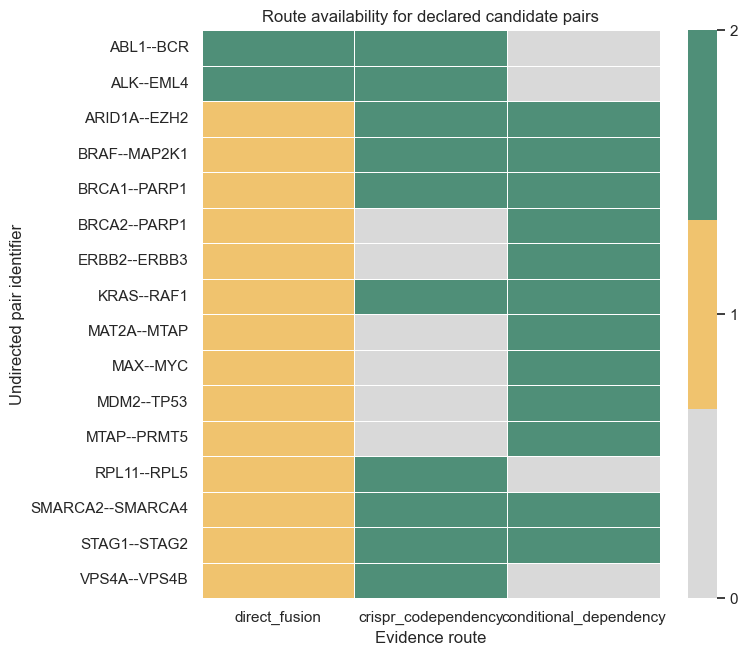

,route_family,route_state,rows
0,conditional_dependency,measured,15
1,conditional_dependency,not_declared_hypothesis,4
2,conditional_dependency,not_measured_context,1
3,crispr_codependency,measured,10
4,crispr_codependency,not_evaluated_candidate_set,6
5,direct_fusion,measured_no_observed_call,14
6,direct_fusion,measured_observed_pair,2


In [6]:
state_score = {
    'measured': 2,
    'measured_observed_pair': 2,
    'measured_no_observed_call': 1,
    'not_measured_context': 1,
    'not_evaluated_candidate_set': 0,
    'not_declared_hypothesis': 0,
}
availability = candidate_evidence.assign(
    availability_score=candidate_evidence['route_state'].map(state_score)
).pivot_table(
    index='pair_id', columns='route_family', values='availability_score', aggfunc='max'
).reindex(columns=['direct_fusion', 'crispr_codependency', 'conditional_dependency'])

plt.figure(figsize=(8, max(5, 0.42 * len(availability))))
sns.heatmap(
    availability, cmap=sns.color_palette(['#d9d9d9', '#f0c36e', '#4f8f78'], as_cmap=True),
    vmin=0, vmax=2, linewidths=0.5, linecolor='white', cbar_kws={'ticks': [0, 1, 2]},
)
plt.title('Route availability for declared candidate pairs')
plt.xlabel('Evidence route')
plt.ylabel('Undirected pair identifier')
plt.tight_layout()
plt.show()

display(candidate_evidence.groupby(['route_family', 'route_state']).size().rename('rows').reset_index())

## 4. Export The Audited Contract

The registry records which fields may be tested later and which must remain visible context. The evidence table is a query-oriented index for the current candidate set. Neither file is a final model matrix, and neither contains a combined cross-route score.

In [7]:
feature_registry.to_csv(PATHS['feature_registry'], index=False)
candidate_evidence.to_csv(PATHS['candidate_evidence'], index=False)

manifest = {
    'source_release': 'DepMap 24Q4 Public',
    'notebook': 'feature_engineering/04_cross_route_feature_admission_audit.ipynb',
    'feature_registry': str(PATHS['feature_registry'].relative_to(PROJECT_ROOT)),
    'candidate_evidence': str(PATHS['candidate_evidence'].relative_to(PROJECT_ROOT)),
    'candidate_pair_count': len(candidate_pairs),
    'feature_registry_rows': len(feature_registry),
    'candidate_evidence_rows': len(candidate_evidence),
    'admitted_candidate_features': feature_registry.loc[
        feature_registry['pre_label_decision'].eq('keep_candidate'),
        ['route_family', 'feature_name']
    ].to_dict(orient='records'),
    'route_rule': 'Direct fusion, CRISPR codependency, and conditional dependency remain separate evidence routes.',
    'missingness_rule': 'Not evaluated or not declared is missing evidence; measured fusion absence is zero only within the known fusion assay denominator.',
    'selection_rule': 'Final predictive feature selection waits for an independent outcome and is performed inside training folds.',
    'held_out_sources': ['PRISM', 'TCGA'],
    'explanation_first_sources': ['Reactome', 'STRING', 'BioGRID'],
}
PATHS['manifest'].write_text(json.dumps(manifest, indent=2), encoding='utf-8')

print(f'Wrote {len(feature_registry):,} registry rows to {PATHS["feature_registry"]}')
print(f'Wrote {len(candidate_evidence):,} evidence rows to {PATHS["candidate_evidence"]}')
print(f'Wrote manifest to {PATHS["manifest"]}')

Wrote 45 registry rows to data\depmap_24Q4\architecture\feature_engineering\cross_route_feature_registry.csv
Wrote 52 evidence rows to data\depmap_24Q4\architecture\feature_engineering\cross_route_candidate_evidence.csv
Wrote manifest to data\depmap_24Q4\architecture\feature_engineering\cross_route_feature_audit_manifest.json


### Decisions carried into the next feature notebook

- Do not fit or calibrate a final predictor until an independent outcome and negative-set definition are agreed.
- Test `models_with_fusion`, `codependency_rho_adjusted`, and `dependency_shift_adjusted` only in their route-specific meanings; technical fusion fields remain separately identified.
- Carry denominators, uncertainty intervals, lineage sensitivity, CRISPR QC, and common-essential warnings beside every route result.
- Select or remove features inside training folds. The current 10-pair and 16-hypothesis candidate sets are too small for correlation-based automatic pruning.
- The next implementation step is reusable route-query code under `preprocessing/`, followed by an independently defined validation-label notebook. It is not a larger master table.